## Importing the Necessary Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

## Loading the Dataset

In [6]:
df = pd.read_csv('German_Credit_Data.csv')
df.head()

,checkin_acc,duration,credit_history,amount,savings_acc,present_emp_since,inst_rate,personal_status,residing_since,age,inst_plans,num_credits,job,status
0,A11,6,A34,1169,A65,A75,4,A93,4,67,A143,2,A173,0
1,A12,48,A32,5951,A61,A73,2,A92,2,22,A143,1,A173,1
2,A14,12,A34,2096,A61,A74,2,A93,3,49,A143,1,A172,0
3,A11,42,A32,7882,A61,A74,2,A93,4,45,A143,1,A173,0
4,A11,24,A33,4870,A61,A73,3,A93,4,53,A143,2,A173,1


## Basic Info on the Dataset

In [8]:
df.shape

(1000, 14)

In [21]:
df.columns

Index(['checkin_acc', 'duration', 'credit_history', 'amount', 'savings_acc',
       'present_emp_since', 'inst_rate', 'personal_status', 'residing_since',
       'age', 'inst_plans', 'num_credits', 'job', 'status'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   checkin_acc        1000 non-null   object
 1   duration           1000 non-null   int64 
 2   credit_history     1000 non-null   object
 3   amount             1000 non-null   int64 
 4   savings_acc        1000 non-null   object
 5   present_emp_since  1000 non-null   object
 6   inst_rate          1000 non-null   int64 
 7   personal_status    1000 non-null   object
 8   residing_since     1000 non-null   int64 
 9   age                1000 non-null   int64 
 10  inst_plans         1000 non-null   object
 11  num_credits        1000 non-null   int64 
 12  job                1000 non-null   object
 13  status             1000 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 109.5+ KB


In [15]:
df.describe()

,duration,amount,inst_rate,residing_since,age,num_credits,status
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,1.000000


In [17]:
df.status.value_counts()

status
0    700
1    300
Name: count, dtype: int64

In [30]:
for i in df.columns:
    if df[i].dtype == 'object':
        print(df[i].value_counts())
    else:
        pass

checkin_acc
A14    394
A11    274
A12    269
A13     63
Name: count, dtype: int64
credit_history
A32    530
A34    293
A33     88
A31     49
A30     40
Name: count, dtype: int64
savings_acc
A61    603
A65    183
A62    103
A63     63
A64     48
Name: count, dtype: int64
present_emp_since
A73    339
A75    253
A74    174
A72    172
A71     62
Name: count, dtype: int64
personal_status
A93    548
A92    310
A94     92
A91     50
Name: count, dtype: int64
inst_plans
A143    814
A141    139
A142     47
Name: count, dtype: int64
job
A173    630
A172    200
A174    148
A171     22
Name: count, dtype: int64


## Encoding the Features

In [33]:
encoded_df = pd.get_dummies(df.iloc[:, :-1])
encoded_df.columns

Index(['duration', 'amount', 'inst_rate', 'residing_since', 'age',
       'num_credits', 'checkin_acc_A11', 'checkin_acc_A12', 'checkin_acc_A13',
       'checkin_acc_A14', 'credit_history_A30', 'credit_history_A31',
       'credit_history_A32', 'credit_history_A33', 'credit_history_A34',
       'savings_acc_A61', 'savings_acc_A62', 'savings_acc_A63',
       'savings_acc_A64', 'savings_acc_A65', 'present_emp_since_A71',
       'present_emp_since_A72', 'present_emp_since_A73',
       'present_emp_since_A74', 'present_emp_since_A75', 'personal_status_A91',
       'personal_status_A92', 'personal_status_A93', 'personal_status_A94',
       'inst_plans_A141', 'inst_plans_A142', 'inst_plans_A143', 'job_A171',
       'job_A172', 'job_A173', 'job_A174'],
      dtype='object')

In [35]:
X = encoded_df
y = df['status']

## Train Test Split

In [38]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

## Decision Tree

In [43]:
from sklearn.tree import DecisionTreeClassifier
modelDT = DecisionTreeClassifier(criterion = 'gini', max_depth = 3)

In [45]:
modelDT.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [47]:
pred_DT = modelDT.predict(x_test)

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [58]:
# Since class labels in Target Column are imbalanced, therefore we should rely on roc_auc_score in this case
print(accuracy_score(y_test, pred_DT))
print(roc_auc_score(y_test, pred_DT))

0.72
0.5787896314212104


# Diplaying the Tree

In [60]:
from sklearn.tree import plot_tree

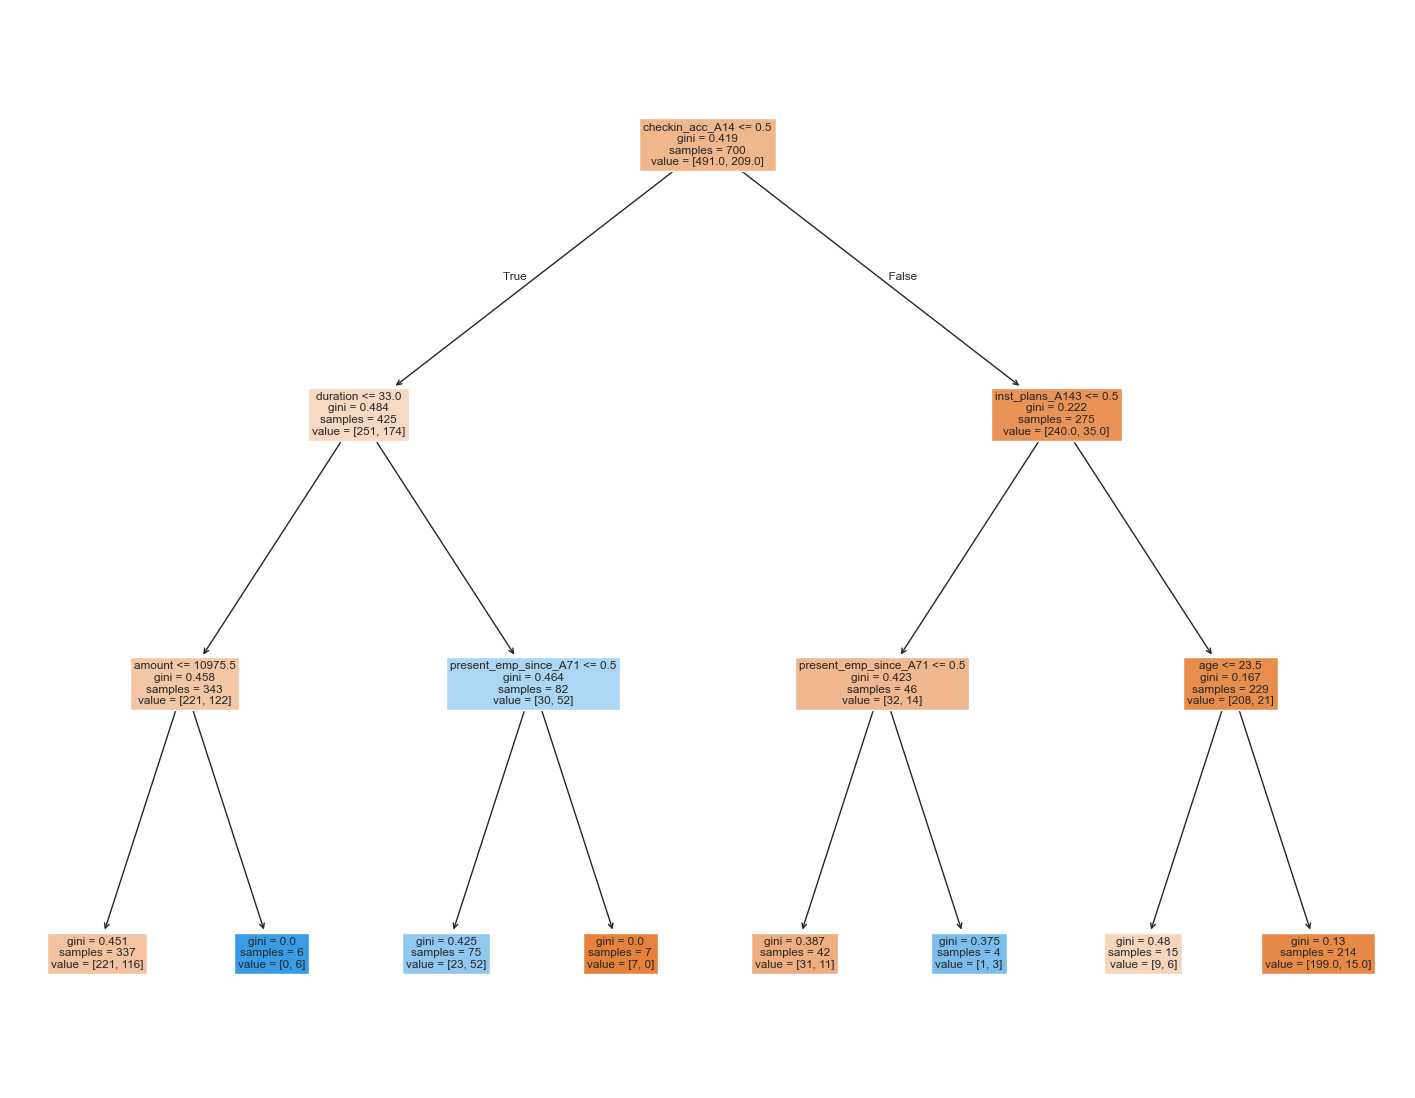

In [66]:
plt.figure(figsize = (18, 14))
_ = plot_tree(modelDT, feature_names = x_train.columns, filled = True)

## Checking roc_auc_score for Hyper-Parameters using GridSearchCV

In [69]:
from sklearn.model_selection import GridSearchCV

In [82]:
params = [{'criterion': ['gini', 'entropy'], 'max_depth': range(2,32)}]
modelDT_GS = GridSearchCV(DecisionTreeClassifier(), params, cv = 10, scoring = 'roc_auc')
modelDT_GS.fit(x_train, y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid=[{'criterion': ['gini', 'entropy'],
                          'max_depth': range(2, 32)}],
             scoring='roc_auc')

In [84]:
modelDT_GS.best_params_

{'criterion': 'entropy', 'max_depth': 4}

In [86]:
modelDT_GS.best_score_

0.7085206997084548

### Prediction Using Best Parameters

In [89]:
pred_DT_GS = modelDT_GS.predict(x_test)

In [91]:
print(confusion_matrix(y_test, pred_DT_GS))

[[193  16]
 [ 69  22]]


In [93]:
print(classification_report(y_test, pred_DT_GS))

              precision    recall  f1-score   support

           0       0.74      0.92      0.82       209
           1       0.58      0.24      0.34        91

    accuracy                           0.72       300
   macro avg       0.66      0.58      0.58       300
weighted avg       0.69      0.72      0.67       300



In [95]:
auc = roc_auc_score(y_test, modelDT_GS.predict_proba(x_test)[:,1])
auc

0.7120248172879752

## Random Forest

In [100]:
from sklearn.ensemble import RandomForestClassifier
no_features = len(X.columns)
model_RF = RandomForestClassifier(max_depth= int(np.log2(no_features)), n_estimators = 100, random_state = 101)
model_RF.fit(x_train, y_train)

RandomForestClassifier(max_depth=5, random_state=101)

In [106]:
pred_RF = model_RF.predict(x_test)
print(accuracy_score(y_test, pred_RF))
print(roc_auc_score(y_test, model_RF.predict_proba(x_test)[:,1]))

0.7366666666666667
0.8004626951995373


## Checking for Multiple Hyper-Parameters using GridSearchCV

In [109]:
params = [{'max_depth': [5,10,15], 'n_estimators': [100, 150, 200], 'max_features': ['sqrt', 0.2, 0.5, 'auto']}]
model_RF_GS = GridSearchCV(RandomForestClassifier(random_state = 101), params, cv = 10, scoring = 'roc_auc')
model_RF_GS.fit(x_train, y_train)

GridSearchCV(cv=10, estimator=RandomForestClassifier(random_state=101),
             param_grid=[{'max_depth': [5, 10, 15],
                          'max_features': ['sqrt', 0.2, 0.5, 'auto'],
                          'n_estimators': [100, 150, 200]}],
             scoring='roc_auc')

In [111]:
print(model_RF_GS.best_score_)
model_RF_GS.best_params_

0.7632396501457726


{'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}

### Prediction Using Best Parameters

In [131]:
model_RF_GS = RandomForestClassifier(max_depth = 10, max_features = 'sqrt', n_estimators = 100, oob_score = True, random_state = 101, n_jobs = -1)
model_RF_GS.fit(x_train, y_train)

RandomForestClassifier(max_depth=10, n_jobs=-1, oob_score=True,
                       random_state=101)

In [133]:
pred_RF_GS = model_RF_GS.predict(x_test)
pred_proba_RF_GS = model_RF_GS.predict_proba(x_test)[:,1]

In [135]:
print(confusion_matrix(y_test, pred_RF_GS))

[[193  16]
 [ 64  27]]


In [137]:
print(classification_report(y_test, pred_RF_GS))

              precision    recall  f1-score   support

           0       0.75      0.92      0.83       209
           1       0.63      0.30      0.40        91

    accuracy                           0.73       300
   macro avg       0.69      0.61      0.62       300
weighted avg       0.71      0.73      0.70       300



In [139]:
auc = roc_auc_score(y_test, pred_proba_RF_GS)
auc

0.772700983227299

In [143]:
model_RF_GS.oob_score_

0.7585714285714286

## Drawing the ROC-AUC Curve

In [170]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

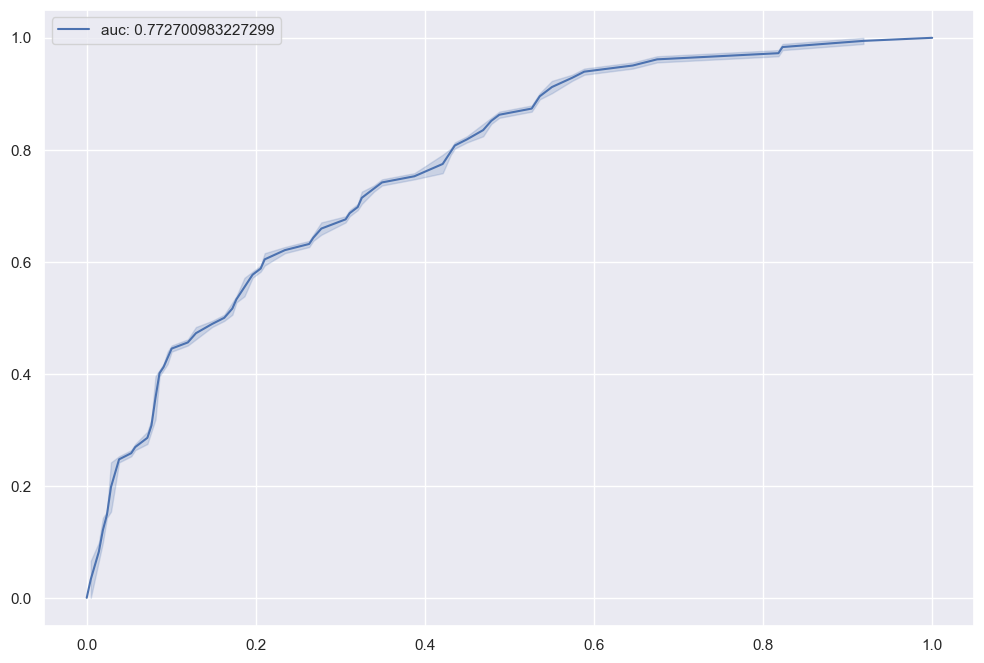

In [160]:
plt.figure(figsize=(12,8))
fpr, tpr, _ = roc_curve(y_test, pred_proba_RF_GS)
sns.lineplot(x = fpr, y = tpr, label = 'auc: '+ str(auc))
plt.show()

In [164]:
fpr, tpr, thresholds = roc_curve(y_test, pred_proba_RF_GS)
roc_auc = auc(fpr,tpr)

<Figure size 2000x1500 with 0 Axes>

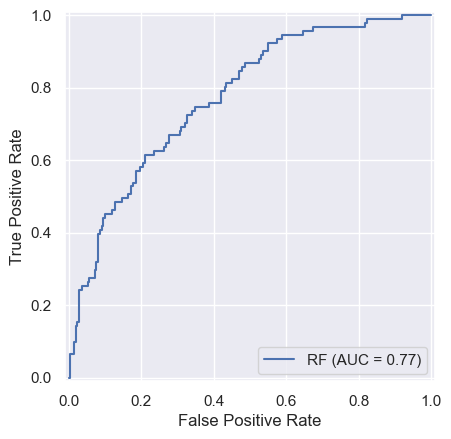

In [176]:
plt.figure(figsize=(20,15))
display = RocCurveDisplay(fpr = fpr, tpr = tpr, roc_auc = roc_auc, estimator_name = 'RF')
display.plot()
plt.show()

## Feature Importance

In [179]:
feature_rank = pd.DataFrame({'feature': x_train.columns, 'importance': model_RF_GS.feature_importances_})

In [181]:
feature_rank = feature_rank.sort_values('importance', ascending = False)

<Axes: xlabel='importance', ylabel='feature'>

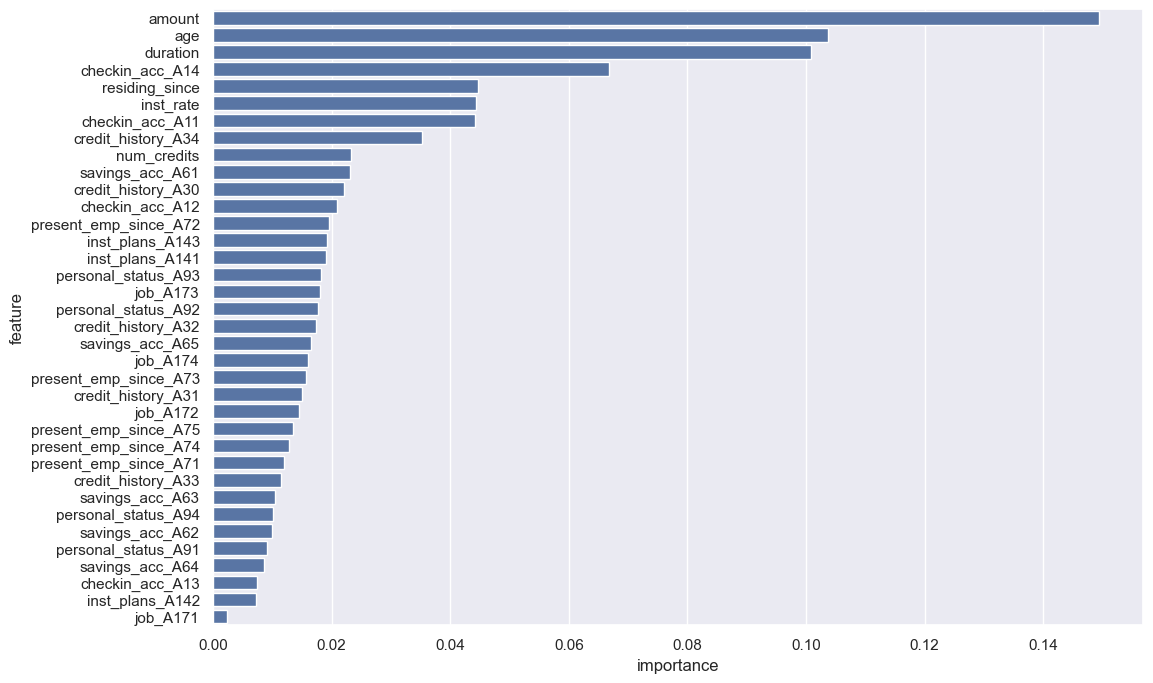

In [183]:
plt.figure(figsize = (12, 8))
sns.barplot(y = 'feature', x = 'importance', data = feature_rank)

In [187]:
feature_rank['cumsum'] = feature_rank.importance.cumsum()*100
feature_rank

,feature,importance,cumsum
1,amount,0.149376,14.937593
4,age,0.103645,25.302094
0,duration,0.100918,35.393874
9,checkin_acc_A14,0.066762,42.070100
3,residing_since,0.044701,46.540202
2,inst_rate,0.044345,50.974752
6,checkin_acc_A11,0.044111,55.385809
14,credit_history_A34,0.035275,58.913327
5,num_credits,0.023245,61.237836
15,savings_acc_A61,0.023152,63.553039


## ADABoost

In [198]:
from sklearn.ensemble import AdaBoostClassifier

In [200]:
dt_base_model = DecisionTreeClassifier()
ada_model = AdaBoostClassifier(dt_base_model, n_estimators = 200, random_state = 101)
ada_model.fit(x_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(), n_estimators=200,
                   random_state=101)

In [202]:
pred_ada = ada_model.predict(x_test)

In [206]:
auc = roc_auc_score(y_test, ada_model.predict_proba(x_test)[:,1])
auc

0.6235606498764393

In [208]:
print(confusion_matrix(y_test, pred_ada))

[[155  54]
 [ 45  46]]


In [210]:
print(classification_report(y_test, pred_ada))

              precision    recall  f1-score   support

           0       0.78      0.74      0.76       209
           1       0.46      0.51      0.48        91

    accuracy                           0.67       300
   macro avg       0.62      0.62      0.62       300
weighted avg       0.68      0.67      0.67       300



## Gradient Boosting

In [215]:
from sklearn.ensemble import GradientBoostingClassifier

In [217]:
model_gb = GradientBoostingClassifier(n_estimators = 500, max_depth = 10, random_state = 101)
model_gb.fit(x_train, y_train)

GradientBoostingClassifier(max_depth=10, n_estimators=500, random_state=101)

In [219]:
auc = roc_auc_score(y_test, model_gb.predict_proba(x_test)[:,1])
auc

0.7718071402281929

## Checking roc-auc for Hyper-Parameters using GridSearchCV

In [234]:
params = [{'n_estimators': [100, 200, 500], 'learning_rate': [0.01, 0.05, .1], 'max_depth': [3, 6, 10]}]
model_gb_gs = GridSearchCV(GradientBoostingClassifier(random_state = 101), params, cv = 10, scoring = 'roc_auc')
model_gb_gs.fit(x_train, y_train)

GridSearchCV(cv=10, estimator=GradientBoostingClassifier(random_state=101),
             param_grid=[{'learning_rate': [0.01, 0.05, 0.1],
                          'max_depth': [3, 6, 10],
                          'n_estimators': [100, 200, 500]}],
             scoring='roc_auc')

In [238]:
model_gb_gs.best_params_

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}

In [240]:
model_gb_gs.best_score_

0.7589073858114674

In [244]:
model_gb_bp = GradientBoostingClassifier(n_estimators = 200, max_depth = 3, learning_rate = 0.05, random_state = 101)
model_gb_bp.fit(x_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=101)

In [250]:
pred_gb_bp = model_gb_bp.predict(x_test)
print(classification_report(y_test, pred_gb_bp))

              precision    recall  f1-score   support

           0       0.77      0.90      0.83       209
           1       0.64      0.38      0.48        91

    accuracy                           0.75       300
   macro avg       0.70      0.64      0.66       300
weighted avg       0.73      0.75      0.73       300



In [252]:
print(confusion_matrix(y_test, pred_gb_bp))

[[189  20]
 [ 56  35]]


In [256]:
auc = roc_auc_score(y_test, model_gb_bp.predict_proba(x_test)[:,1])
auc

0.7554287817445712

## ROC-AUC Curve

In [275]:
fpr, tpr, thresholds = roc_curve(y_test, model_gb_bp.predict_proba(x_test)[:,1])
disp = RocCurveDisplay(fpr = fpr, tpr = tpr, roc_auc = auc, estimator_name = 'Gradient Boosting')

<Figure size 1500x1000 with 0 Axes>

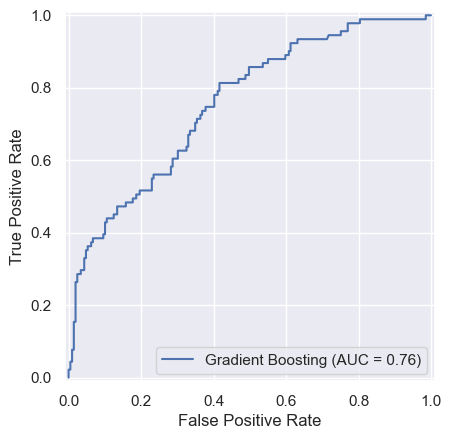

In [277]:
plt.figure(figsize = (15,10))
disp.plot()

## XGBoost

In [280]:
pip install xgboost

   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/56.8 MB 5.6 MB/s eta 0:00:11
    --------------------------------------- 1.0/56.8 MB 3.6 MB/s eta 0:00:16
   - -------------------------------------- 1.8/56.8 MB 3.2 MB/s eta 0:00:17
   - -------------------------------------- 2.1/56.8 MB 2.8 MB/s eta 0:00:20
   - -------------------------------------- 2.6/56.8 MB 2.8 MB/s eta 0:00:20
   -- ------------------------------------- 3.4/56.8 MB 2.8 MB/s eta 0:00:19
   -- ------------------------------------- 3.9/56.8 MB 2.8 MB/s eta 0:00:19
   --- ------------------------------------ 4.5/56.8 MB 2.9 MB/s eta 0:00:19
   --- ------------------------------------ 5.2/56.8 MB 2.9 MB/s eta 0:00:18
   ---- ----------------------------------- 6.6/56.8 MB 3.2 MB/s eta 0:00:16
   ---- ----------------------------------- 7.1/56.8 MB 3.3 MB/s eta 0:00:16
   ----- ---------------------------------- 8.1/56.8 MB 3.4 MB/s eta 0:00:15
   ---

In [284]:
from xgboost import XGBClassifier

In [299]:
model_XGB = XGBClassifier(objective = 'binary:logistic', n_estimators = 500, learning_rate = 0.1, random_state = 101, n_jobs = -1, max_depth = 4)
model_XGB.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

In [301]:
auc = roc_auc_score(y_test, model_XGB.predict_proba(x_test)[:,1])
auc

0.7901046322098954

## Checking roc-auc for hyper-Parameters using GridSearchCV

In [306]:
params = [{'n_estimators': [200, 3000, 500], 'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [3,5,8]}]
model_XGB_gs = GridSearchCV(XGBClassifier(random_state = 101,  objective= 'binary:logistic', n_jobs = -1), params, cv = 10, scoring = 'roc_auc')
model_XGB_gs.fit(x_train, y_train)

GridSearchCV(cv=10,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=-1, num_parallel_tree=None, ...),
             param_grid=[{'learning_rate': [0.01, 0.05, 0.1],
                          'max_depth': [3, 5, 8],
                          'n_estimators': [200, 3000, 500]}],
             scoring='roc_auc')

In [308]:
model_XGB_gs.best_params_

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}

In [310]:
model_XGB_gs.best_score_

0.7574609329446064

In [312]:
model_XGB_bp = XGBClassifier(n_estimator = 200, learning_rate = 0.05, max_depth = 3, objective = 'binary:logistic', n_jobs = -1, random_state = 101)
model_XGB_bp.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimator=200,
              n_estimators=None, n_jobs=-1, ...)

In [314]:
pred_y = model_XGB_bp.predict(x_test)

In [316]:
print(confusion_matrix(y_test,pred_y))

[[193  16]
 [ 55  36]]


In [320]:
print(classification_report(y_test, pred_y))

              precision    recall  f1-score   support

           0       0.78      0.92      0.84       209
           1       0.69      0.40      0.50        91

    accuracy                           0.76       300
   macro avg       0.74      0.66      0.67       300
weighted avg       0.75      0.76      0.74       300



In [324]:
auc = roc_auc_score(y_test, model_XGB_bp.predict_proba(x_test)[:,1])
auc

0.786134917713865

In [326]:
fpr, tpr, thresholds = roc_curve(y_test, model_gb_bp.predict_proba(x_test)[:,1])
disp = RocCurveDisplay(fpr = fpr, tpr = tpr, roc_auc = auc, estimator_name = 'XGBoosting')

<Figure size 1500x1000 with 0 Axes>

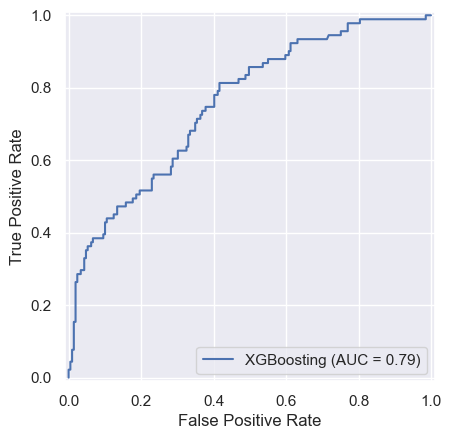

In [328]:
plt.figure(figsize = (15,10))
disp.plot()